In [1]:
import numpy as np
import cv2 #to work with images
from skimage.io import imread
from skimage.measure import label, regionprops_table #to get shape properties
import pandas as pd #make spreadsheet
from scipy import ndimage as ndi #for watershed segmentation
from skimage.feature import peak_local_max #for watershed segmentation
from skimage.segmentation import watershed #for watershed segmentation
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from skimage.color import label2rgb
from skimage.morphology import dilation, disk

In [2]:
def get_labels(img):
    distance = ndi.distance_transform_edt(img)
    local_max_coords = peak_local_max(distance, min_distance=50)
    local_max_mask = np.zeros(distance.shape, dtype=bool)
    local_max_mask[tuple(local_max_coords.T)] = True
    markers = label(local_max_mask)
    segmented_cells = watershed(-distance, markers, mask=img)
    return segmented_cells

In [3]:
def new_method(img):
    distance = ndi.distance_transform_edt(img)
    sure_fg_mask = distance > 0.3 * distance.max()
    markers = label(sure_fg_mask)
    sure_bg_mask = dilation(img, disk(5))
    markers[sure_bg_mask == 0] = markers.max() + 1
    segmented_cells = watershed(-distance, markers, mask=img)
    return segmented_cells

In [4]:
def get_axon_row(axon_df, left, right, top, bottom):
    '''
    Using the myelin bounding box find the larges axon that correspons to that myelin
    '''
    
    left = int(left)
    right = int(right)
    top = int(top)
    bottom = int(bottom)
    
    axons_id = axon_df[(((axon_df['centroid-0'])>=left) & (axon_df['centroid-0']<=right)) &
                       ((axon_df['centroid-1'])>=top) & (axon_df['centroid-1']<=bottom)]
    biggest_axon = axons_id[axons_id['area'] == axons_id['area'].max()]
    
    return biggest_axon


In [5]:
def get_morphometrics(img_path):
    '''
    Get morphometric data from a single image and return a pandas df of the morphometric data
    
    :param img_path: A path (string or object) pointing to a single segmented image in which the myelin is a middle grey and the axon is white
    
    :returns: Pandas DataFrame; morphometrics
    '''
    
    #read the image and flatten it into black and white
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    axon = cv2.inRange(img, 200, 255) #axons are everything above a medium gray
    myelin = cv2.inRange(img, 1, 255) #myelin is actually axon+myelin so everything above black
    
    #watershed labelling of axons then obtaining region properties and putting it in a DataFrame
    axon_label = get_labels(axon)
    axon_props = regionprops_table(axon_label,properties=('label', 'centroid', 'area', 'axis_minor_length', 'axis_major_length', 
                                                          'eccentricity', 'orientation', 'perimeter', 'solidity'))
    axon_df = pd.DataFrame.from_dict(axon_props)

    #watershed labelling of myelin then obtaining region properties and putting it in a DataFrame
    myelin_label = get_labels(myelin)
    myelin_props = regionprops_table(myelin_label, properties=('label', 'bbox', 'area', 'axis_minor_length', 'axis_major_length',
                                                               'perimeter'))
    myelin_df = pd.DataFrame.from_dict(myelin_props)
    
    #making an empty DataFrame to put morphometric data into
    columns = {'label':[],
               'x':[],
               'y':[],
               'axon_area':[],
               'axon_perimeter':[],
               'axon_diam':[],
               'myelin_area':[],
               'myelin_thickness':[],
               'myelin_perimeter':[],
               'eccentricity':[],
               'orientation':[],
               'solidity':[],
               'gratio':[]}
    morph_df1 = pd.DataFrame(columns)
    morph_df2 = pd.DataFrame(columns)
    
    #going through all the myelin that got accounted for in watershed
    #using myelin to compare to axons
    drop_rows = []    
    for index, row in myelin_df.iterrows():
        left = row['bbox-0']
        right = row['bbox-2']
        top = row['bbox-1']
        bottom = row['bbox-3']
        
        axon_row = get_axon_row(axon_df, left, right, top, bottom)
        if not(axon_row.empty):
            label = row['label']
            x = axon_row['centroid-0']
            y = axon_row['centroid-1']
            axon_area = axon_row['area']
            axon_perimeter = axon_row['perimeter']
            axon_diam = axon_row['axis_major_length']#(row['axis_major_length'] + row['axis_minor_length']) / 2 #getting axon diameter along the major axis
            eccentricity = axon_row['eccentricity']
            orientation = axon_row['orientation']
            solidity = axon_row['solidity']
            
            myelin_area = row['area'] - axon_area
            myelin_thickness = row['axis_major_length']
            myelin_perimeter = row['perimeter']
            gratio = axon_diam / row['axis_major_length']
            
            if gratio.iloc[0] < 1:
                #make a one row DataFrame with axon and myelin data
                new_dict = {'label':label,
                        'x':x,
                        'y':y,
                        'axon_area':axon_area,
                        'axon_perimeter':axon_perimeter,
                        'axon_diam':axon_diam,
                        'myelin_area':myelin_area,
                        'myelin_thickness':myelin_thickness,
                        'myelin_perimeter':myelin_perimeter,
                        'eccentricity':eccentricity,
                        'orientation':orientation,
                        'solidity':solidity,
                        'gratio':gratio}

                new_df = pd.DataFrame(new_dict)
                
                #add the new data to the morphometrics DataFrame
                morph_df2 = pd.concat([morph_df2,new_df], ignore_index=True)
        
    morph_df2 = morph_df2.drop(drop_rows)
    return axon_label, myelin_label, morph_df2

In [6]:
def get_morphometrics_new(img_path):
    '''
    Get morphometric data from a single image and return a pandas df of the morphometric data
    
    :param img_path: A path (string or object) pointing to a single segmented image in which the myelin is a middle grey and the axon is white
    
    :returns: Pandas DataFrame; morphometrics
    '''
    
    #read the image and flatten it into black and white
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    axon = cv2.inRange(img, 200, 255) #axons are everything above a medium gray
    myelin = cv2.inRange(img, 1, 255) #myelin is actually axon+myelin so everything above black
    
    #watershed labelling of axons then obtaining region properties and putting it in a DataFrame
    axon_label = new_method(axon)
    axon_props = regionprops_table(axon_label,properties=('label', 'centroid', 'area', 'axis_minor_length', 'axis_major_length', 
                                                          'eccentricity', 'orientation', 'perimeter', 'solidity'))
    axon_df = pd.DataFrame.from_dict(axon_props)

    #watershed labelling of myelin then obtaining region properties and putting it in a DataFrame
    myelin_label = new_method(myelin)
    myelin_props = regionprops_table(myelin_label, properties=('label', 'bbox', 'area', 'axis_minor_length', 'axis_major_length',
                                                               'perimeter'))
    myelin_df = pd.DataFrame.from_dict(myelin_props)
    
    #making an empty DataFrame to put morphometric data into
    columns = {'label':[],
               'x':[],
               'y':[],
               'axon_area':[],
               'axon_perimeter':[],
               'axon_diam':[],
               'myelin_area':[],
               'myelin_thickness':[],
               'myelin_perimeter':[],
               'eccentricity':[],
               'orientation':[],
               'solidity':[],
               'gratio':[]}
    morph_df1 = pd.DataFrame(columns)
    morph_df2 = pd.DataFrame(columns)
    
    #going through all the myelin that got accounted for in watershed
    #using myelin to compare to axons
    drop_rows = []    
    for index, row in myelin_df.iterrows():
        left = row['bbox-0']
        right = row['bbox-2']
        top = row['bbox-1']
        bottom = row['bbox-3']
        
        axon_row = get_axon_row(axon_df, left, right, top, bottom)
        if not(axon_row.empty):
            label = row['label']
            x = axon_row['centroid-0']
            y = axon_row['centroid-1']
            axon_area = axon_row['area']
            axon_perimeter = axon_row['perimeter']
            axon_diam = axon_row['axis_major_length']#(row['axis_major_length'] + row['axis_minor_length']) / 2 #getting axon diameter along the major axis
            eccentricity = axon_row['eccentricity']
            orientation = axon_row['orientation']
            solidity = axon_row['solidity']
            
            myelin_area = row['area'] - axon_area
            myelin_thickness = row['axis_major_length']
            myelin_perimeter = row['perimeter']
            gratio = axon_diam / row['axis_major_length']
            
            if gratio.iloc[0] < 1:
                #make a one row DataFrame with axon and myelin data
                new_dict = {'label':label,
                        'x':x,
                        'y':y,
                        'axon_area':axon_area,
                        'axon_perimeter':axon_perimeter,
                        'axon_diam':axon_diam,
                        'myelin_area':myelin_area,
                        'myelin_thickness':myelin_thickness,
                        'myelin_perimeter':myelin_perimeter,
                        'eccentricity':eccentricity,
                        'orientation':orientation,
                        'solidity':solidity,
                        'gratio':gratio}

                new_df = pd.DataFrame(new_dict)
                
                #add the new data to the morphometrics DataFrame
                morph_df2 = pd.concat([morph_df2,new_df], ignore_index=True)
        
    morph_df2 = morph_df2.drop(drop_rows)
    return axon_label, myelin_label, morph_df2

In [30]:
test_img = r"T:\Orthopaedics\Lab Imaging Data\mmazur\NT_Validation_Study4\Rb60180\Rb60180_Left_A\40X_Segmented\Rb60180_LA_40X_005r_seg.tif"
img = cv2.imread(test_img, 0)

In [31]:
axons_original, myelin_original, df_original = get_morphometrics_new(test_img)
df_original

,label,x,y,axon_area,axon_perimeter,axon_diam,myelin_area,myelin_thickness,myelin_perimeter,eccentricity,orientation,solidity,gratio
0,4.0,5.076433,160.486200,471.0,113.284271,50.218403,2647.0,105.398232,262.024387,0.965439,-1.531570,0.873840,0.476463
1,6.0,3.582329,268.393574,249.0,83.556349,35.847152,207.0,42.558952,105.112698,0.961664,-1.461845,0.889286,0.842294
2,8.0,6.492683,451.765854,410.0,87.591883,34.753495,836.0,63.011651,178.882251,0.893379,1.391862,0.946882,0.551541
3,9.0,2.555556,596.751323,189.0,75.520815,35.028311,793.0,90.903384,185.597980,0.973349,-1.565270,0.836283,0.385336
4,10.0,2.175610,684.307317,205.0,91.591883,46.026957,357.0,68.538670,150.213203,0.989104,1.521916,0.857741,0.671547
...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,535.0,967.621079,1239.202008,797.0,139.882251,53.900658,1701.0,71.645321,263.421356,0.915521,1.271273,0.864425,0.752326
136,536.0,965.054167,1135.883333,240.0,58.870058,22.221014,733.0,38.382230,137.639610,0.770771,-0.388152,0.933852,0.578940
137,539.0,976.300330,27.089109,303.0,70.870058,23.384594,1525.0,72.900865,201.823376,0.646422,-1.339618,0.912651,0.320773
138,555.0,1018.405405,881.915058,259.0,85.941125,36.582084,1136.0,65.319320,211.681241,0.947968,1.419751,0.768546,0.560050


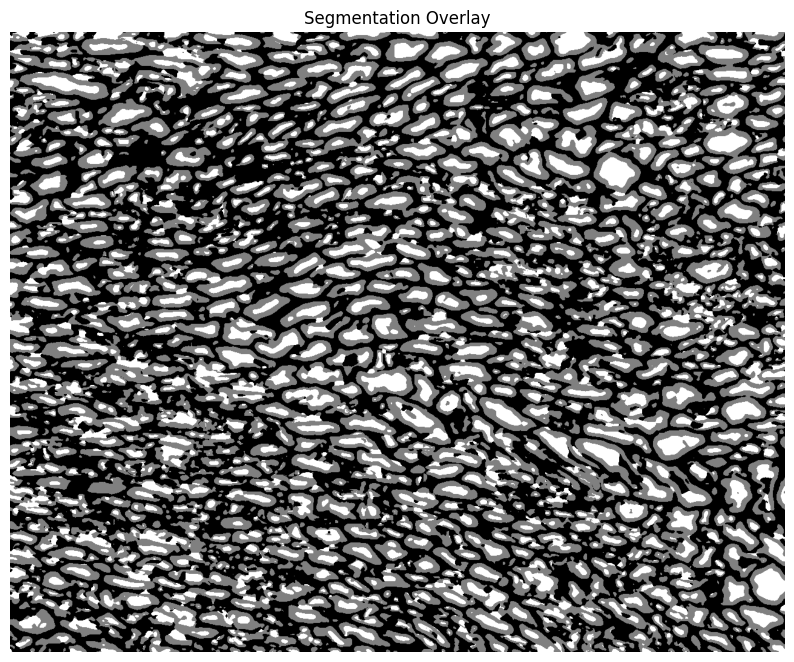

In [32]:
plt.figure(figsize=(10,10))
plt.imshow(img, cmap='gray')
plt.title('Original Image, alpha=0.4')
plt.title("Segmentation Overlay")
plt.axis("off")
plt.show()

TypeError: Image data of dtype <U14 cannot be converted to float

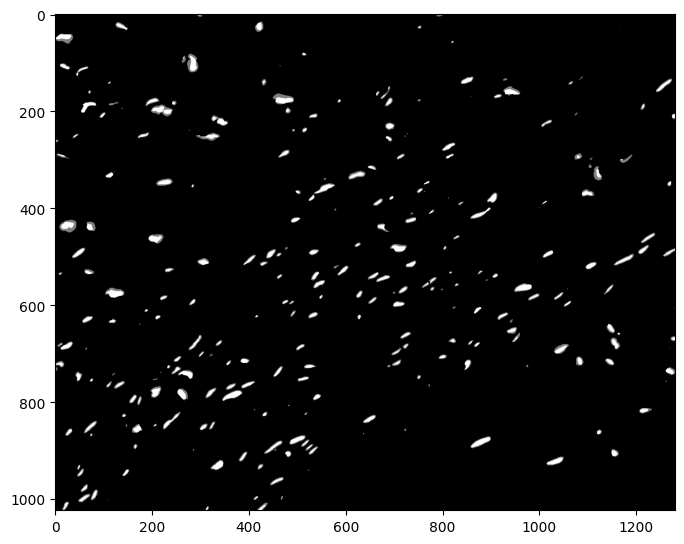

In [10]:

plt.figure(figsize=(8,8))
plt.imshow(img, cmap='gray')
plt.imshow('Original Image', alpha=0.4)

plt.title("Segmentation Overlay")
plt.axis("off")
plt.show()

C:\Users\mazurm\AppData\Local\Temp\ipykernel_36440\341172973.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', num_labels+1)  # tab20 has 20 colors, can pick bigger


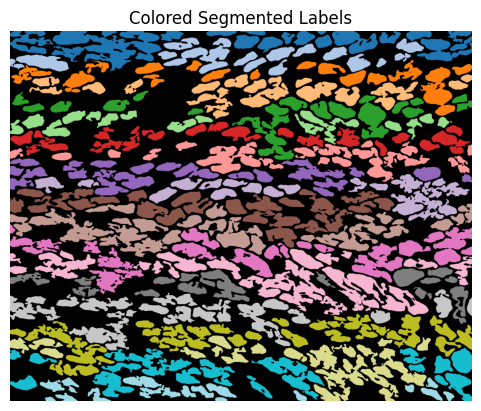

In [33]:
# Convert labels to RGB image with unique colors
myelin_labels = label(myelin_original > 0)  # threshold if needed
num_labels = myelin_labels.max()
cmap = cm.get_cmap('tab20', num_labels+1)  # tab20 has 20 colors, can pick bigger

colored_labels = label2rgb(myelin_labels, colors=[cmap(i)[:3] for i in range(num_labels+1)], bg_label=0)

# Display
plt.imshow(colored_labels)
plt.title("Colored Segmented Labels")
plt.axis('off')
plt.show()

In [ ]:
axons, myelin, df = get_morphometrics_new(test_img)
df

In [18]:
# Convert labels to RGB image with unique colors
colored_labels = label2rgb(myelin, bg_label=0)

# Display
plt.imshow(colored_labels)
plt.title("Colored Segmented Labels")
plt.axis('off')
plt.show()

NameError: name 'myelin' is not defined

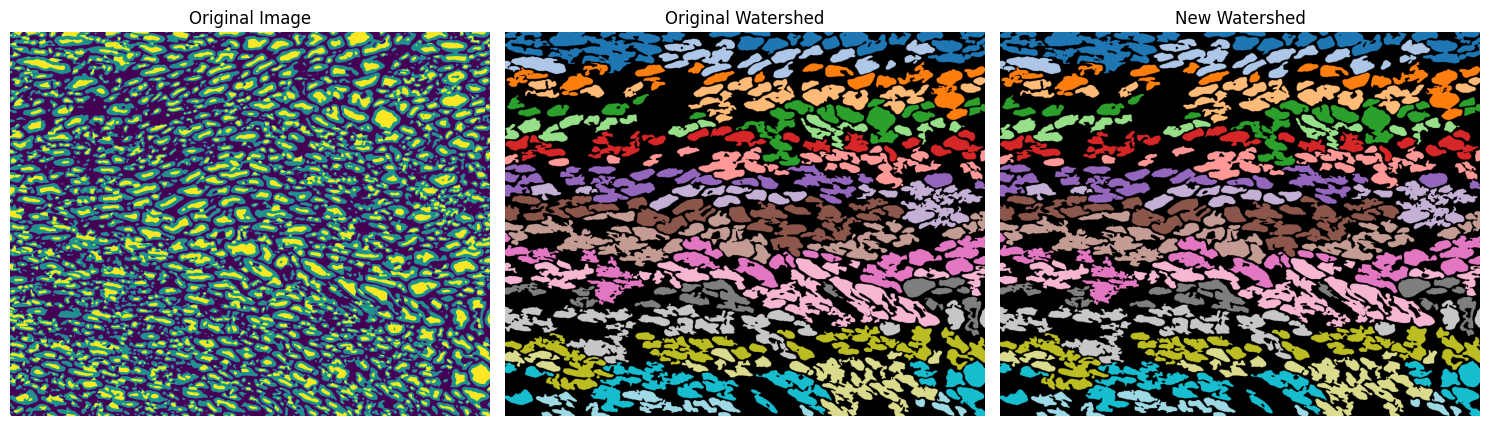

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off') # Hide the axes ticks

axes[1].imshow(colored_labels)
axes[1].set_title('Original Watershed')
axes[1].axis('off')

axes[2].imshow(colored_labels)
axes[2].set_title('New Watershed')
axes[2].axis('off')

plt.tight_layout()

plt.show()

NameError: name 'df' is not defined

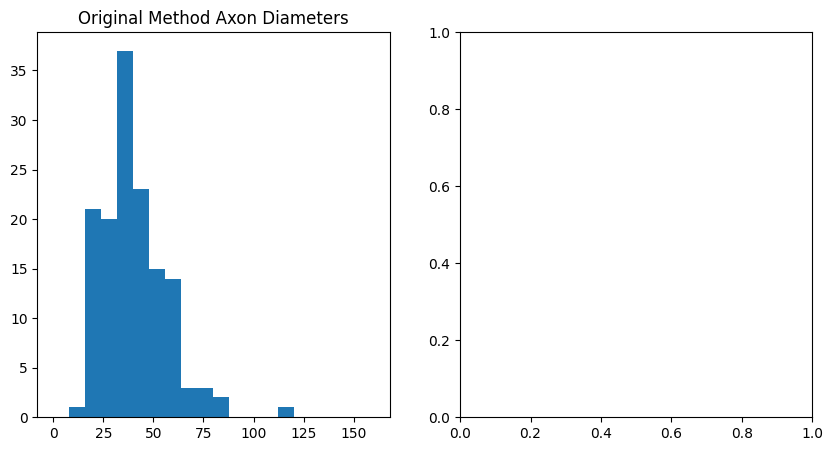

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].hist(df_original['axon_diam'], bins=20, range=(0, 160))
axes[0].set_title('Original Method Axon Diameters')

axes[1].hist(df['axon_diam'], bins=20, range=(0, 160))
axes[1].set_title('New Method Axon Diameters')

plt.tight_layout()

plt.show()

In [37]:
import napari

# -----------------------------
# Paths to your image folders
# -----------------------------
image_folder = r"T:\Orthopaedics\Lab Imaging Data\mmazur\NT_Validation_Study4\Rb60188\Rb60188_Left_A\40X_TIFF"
overlay_folder = r"T:\Orthopaedics\Lab Imaging Data\mmazur\NT_Validation_Study4\Rb60188\Rb60188_Left_A\40X_Segmented"

# -----------------------------
# Get sorted file lists
# -----------------------------
img_files = sorted([f for f in os.listdir(image_folder) if f.lower().endswith(('.tif', '.tiff'))])
overlay_files = sorted([f for f in os.listdir(overlay_folder) if f.lower().endswith(('.tif', '.tiff'))])

num_images = min(len(img_files), len(overlay_files))
print(f"Found {num_images} images with overlays.")

# -----------------------------
# Load first image + overlay
# -----------------------------
def load_image(path):
    img = imread(path)
    # Handle OME-TIFF channel-last shape
    if img.ndim == 3 and img.shape[-1] in [3,4]:  # RGB or RGBA
        img = np.transpose(img, (2, 0, 1))       # HWC -> CHW for napari
    return img.astype(np.float32)

img = load_image(os.path.join(image_folder, img_files[0]))
overlay = load_image(os.path.join(overlay_folder, overlay_files[0]))

# -----------------------------
# Start Napari viewer
# -----------------------------
viewer = napari.Viewer()

# Add two layers (Original + Overlay)
img_layer = viewer.add_image(img, name='Original', blending='additive')
overlay_layer = viewer.add_image(overlay, name='Overlay', opacity=0.4, blending='additive')

# -----------------------------
# Scroll-through helper
# -----------------------------
current_index = 0

def show_next_image():
    """Update layers to next image/overlay"""
    global current_index
    current_index = (current_index + 1) % num_images
    img_layer.data = load_image(os.path.join(image_folder, img_files[current_index]))
    overlay_layer.data = load_image(os.path.join(overlay_folder, overlay_files[current_index]))

def show_prev_image():
    """Update layers to previous image/overlay"""
    global current_index
    current_index = (current_index - 1) % num_images
    img_layer.data = load_image(os.path.join(image_folder, img_files[current_index]))
    overlay_layer.data = load_image(os.path.join(overlay_folder, overlay_files[current_index]))

# -----------------------------
# Optional: Keyboard shortcuts
# -----------------------------
viewer.bind_key('Right', show_next_image)  # Right arrow -> next image
viewer.bind_key('Left', show_prev_image)   # Left arrow -> previous image

napari.run()

Found 4 images with overlays.
